In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [7]:
import time

def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()

        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

W = ch.ones(1, 1)
NOISE_VAR = 1.0
def phi(x): 
    return x > 0

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, 1000, W, NOISE_VAR, verbose=True)

alpha: 0.671


# One Dimension Regression - Varying Samples

In [11]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [1.0136285]


In [12]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.677
trunc lin reg W:
 [[1.5792587]]


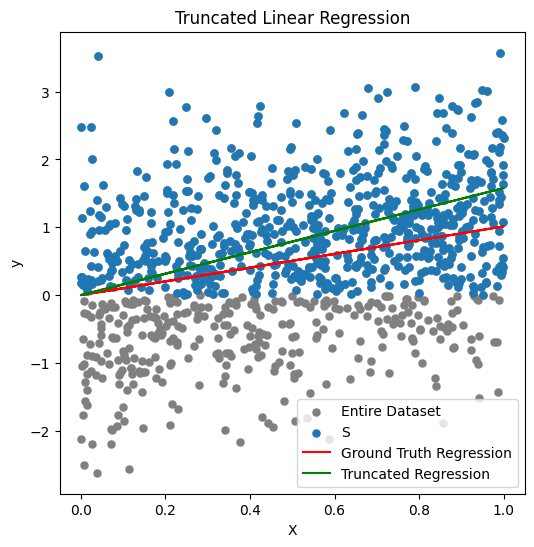

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [25]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)
NOISE_VAR = 1.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR)

        gt = LinearRegression(fit_intercept=False)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten()]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=False)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc) - y_trunc.numpy()).var(0)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten()]))

        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        y_trunc_emp_scale = y_trunc / ch.sqrt(emp_noise_var)

        args = Parameters({
                            'trials': 1,
                            'batch_size': 10,
                            'var_lr': 1e-2, 
                            'early_stopping': True,
#                             'step_lr': 1.0,
                            'gradient_steps': num_samples,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha, 
                                                fit_intercept=False)
        delphi_reg.fit(x_trunc, y_trunc_emp_scale)

        delphi_coef_ = delphi_reg.best_coef_ * (emp_noise_var ** .5)
        delphi_var_ = delphi_reg.best_variance_ * emp_noise_var

        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1
        }

        results.append(result)
    
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
trial: 1, num samples: 500
trial: 1, num samples: 1000
trial: 1, num samples: 2000
trial: 1, num samples: 3000
trial: 1, num samples: 4000
trial: 1, num samples: 5000
trial: 1, num samples: 6000
trial: 1, num samples: 7000
trial: 1, num samples: 8000
trial: 1, num samples: 9000
trial: 1, num samples: 10000
trial: 2, num samples: 100
trial: 2, num samples: 500
trial: 2, num samples: 1000
trial: 2, num samples: 2000
trial: 2, num samples: 3000
trial: 2, num samples: 4000
trial: 2, num samples: 5000
trial: 2, num samples: 6000
trial: 2, num samples: 7000
trial: 2, num samples: 8000
trial: 2, num samples: 9000
trial: 2, num samples: 10000
trial: 3, num samples: 100
trial: 3, num samples: 500
trial: 3, num samples: 1000
trial: 3, num samples: 2000
trial: 3, num samples: 3000
trial: 3, num samples: 4000
trial: 3, num samples: 5000
trial: 3, num samples: 6000
trial: 3, num samples: 7000
trial: 3, num samples: 8000
trial: 3, num samples: 9000
trial: 3, num samples: 1

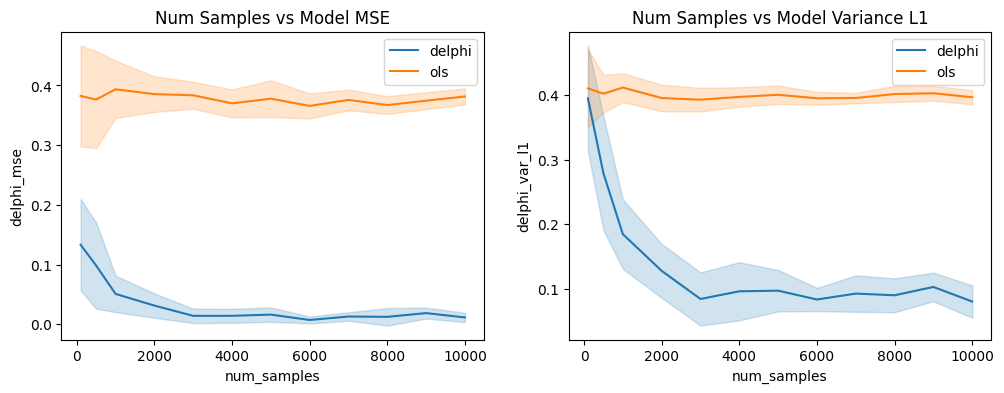

In [26]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

plt.show()

# 10 Dimension Truncated Regression - Varying Samples

In [78]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 5

D = 10
W = ch.ones(D, 1)
NOISE_VAR = 1.0

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
# NUM_SAMPLES = [20000]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR, D=D, verbose=True)

        gt = LinearRegression()
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression()
        ols_trunc.fit(x_trunc, y_trunc)
        emp_noise_var = ch.from_numpy(ols_trunc.predict(x_trunc) - y_trunc.numpy()).var(0)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))

        emp_mse_loss = mse_loss(emp_, gt_).item()
        emp_var_l1 = float(ch.abs(emp_noise_var - gt_noise_var))

        y_trunc_emp_scale = y_trunc / ch.sqrt(emp_noise_var)
        
        def phi_emp_scale(X): 
            return X > (5 / ch.sqrt(emp_noise_var))

        args = Parameters({
                            'trials': 1,
                            'batch_size': 100,
                            'var_lr': 1e-2, 
                            'early_stopping': True,
#                             'step_lr_gamma': 1.0,
                            'step_lr': 500,
                            'gradient_steps': num_samples,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi_emp_scale,
                                                alpha)
        delphi_reg.fit(x_trunc, y_trunc_emp_scale)

        delphi_ = ch.concatenate([delphi_reg.best_coef_.flatten() * (emp_noise_var ** .5), delphi_reg.best_intercept_]) 
        delphi_var_ = delphi_reg.best_variance_ * emp_noise_var

        delphi_mse = mse_loss(gt_, delphi_).item()
        delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'emp_var_l1': emp_var_l1, 
            'delphi_mse': delphi_mse, 
            'delphi_var_l1': delphi_var_l1
        }

        results.append(result)
    
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
alpha: 0.460
trial: 1, num samples: 500
alpha: 0.492
trial: 1, num samples: 1000
alpha: 0.491
trial: 1, num samples: 2000
alpha: 0.500
trial: 1, num samples: 3000
alpha: 0.519
trial: 1, num samples: 4000
alpha: 0.485
trial: 1, num samples: 5000
alpha: 0.502
trial: 1, num samples: 6000
alpha: 0.508
trial: 1, num samples: 7000
alpha: 0.511
trial: 1, num samples: 8000
alpha: 0.507
trial: 1, num samples: 9000
alpha: 0.499
trial: 1, num samples: 10000
alpha: 0.495
trial: 2, num samples: 100
alpha: 0.530
trial: 2, num samples: 500
alpha: 0.501
trial: 2, num samples: 1000
alpha: 0.499
trial: 2, num samples: 2000
alpha: 0.507
trial: 2, num samples: 3000
alpha: 0.500
trial: 2, num samples: 4000
alpha: 0.497
trial: 2, num samples: 5000
alpha: 0.503
trial: 2, num samples: 6000
alpha: 0.503
trial: 2, num samples: 7000
alpha: 0.494
trial: 2, num samples: 8000
alpha: 0.502
trial: 2, num samples: 9000
alpha: 0.508
trial: 2, num samples: 10000
alpha: 0.497
trial: 3, num samp

KeyboardInterrupt: 

In [79]:
df = pd.DataFrame(results)

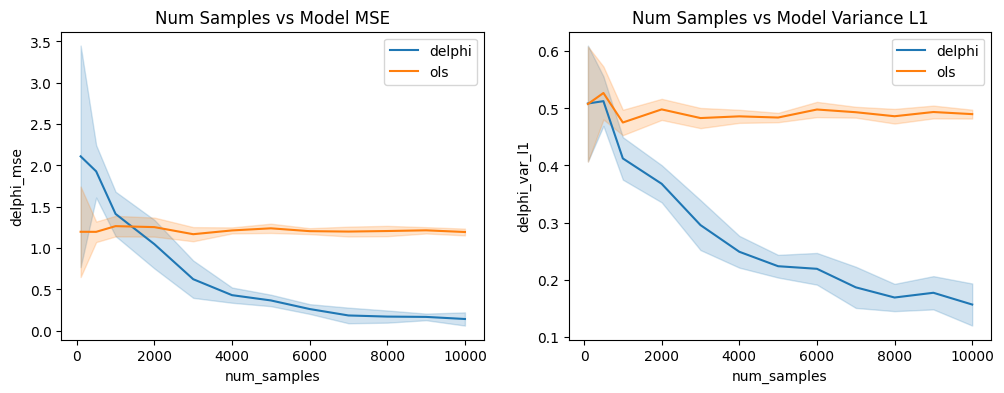

In [80]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax1, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax1, label="ols")
ax1.set_title('Num Samples vs Model MSE')

sns.lineplot(data=df, x="num_samples", y="delphi_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_var_l1", estimator="mean", errorbar="sd", ax=ax2, label="ols")
ax2.set_title('Num Samples vs Model Variance L1')

plt.show()

In [75]:
results

[{'num_samples': 20000,
  'emp_mse': 1.2263007164001465,
  'emp_var_l1': 0.4903761148452759,
  'delphi_mse': 0.10674578696489334,
  'delphi_var_l1': 0.13494819402694702}]